# 5. Modeling Distributions

## 5.7. Glossary

| Term | Definition |
|------|-----------|
| binomial distribution | A theoretical distribution often used to model the number of successes or hits in a sequence of hits and misses. |
| Poisson distribution | A theoretical distribution often used to model the number of events that occur in an interval of time. |
| exponential distribution | A theoretical distribution often used to model the time between events. |
| normal distribution | A theoretical distribution often used to model data that follow a symmetric, bell-like curve. |
| lognormal distribution | A theoretical distribution often used to model data that follow a bell-like curve that is skewed to the right. |

## 5.1. The Binomial Distribution

https://www.youtube.com/watch?v=6YzrVUVO9M0&t=526s

In [1]:
import sys
sys.path.append('../nb')

import numpy as np
import matplotlib.pyplot as plt
from thinkstats import decorate

def flip(n, p):
    choices = [1, 0]
    probs = [p, 1 - p]
    return np.random.choice(choices, n, p=probs)

In [2]:
# Seed the random number generator so we get the same results every time
np.random.seed(1)

flip(25, 0.9)

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1])

In [3]:
from empiricaldist import Pmf

seq = flip(1000, 0.9)
pmf = Pmf.from_seq(seq)
pmf

,probs
0,0.101
1,0.899


In [4]:
def simulate_round(n, p):
    seq = flip(n, p)
    return seq.sum()

In [5]:
n = 25
p = 0.9
results_sim = [simulate_round(n, p) for i in range(1000)]

The average score is close to 22.5, which is the product of n and p.

In [6]:
np.mean(results_sim), n * p

(np.float64(22.522), 22.5)

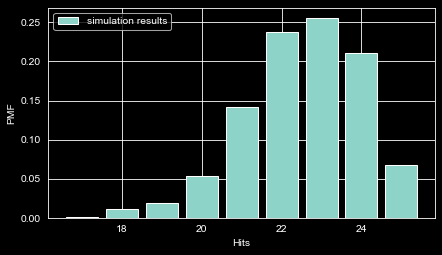

In [7]:
from empiricaldist import Pmf

pmf_sim = Pmf.from_seq(results_sim, name="simulation results")

pmf_sim.bar()
decorate(xlabel="Hits", ylabel="PMF")

Instead of running a simulation, we could have predicted this distribution. Mathematically, the distribution of these outcomes follows a binomial distribution, which has a PMF that is easy to compute.

In [8]:
from scipy.special import comb


def binomial_pmf(k, n, p):
    return comb(n, k) * (p**k) * ((1 - p) ** (n - k))

SciPy provides the comb function, which computes the number of combinations of n things taken k at a time, often pronounced “n choose k”.

binomial_pmf computes the probability of getting k hits out of n attempts, given p. If we call this function with a range of k values, we can make a Pmf that represents the distribution of the outcomes.

In [9]:
ks = np.arange(16, n + 1)
ps = binomial_pmf(ks, n, p)
pmf_binom = Pmf(ps, ks, name="binomial model")

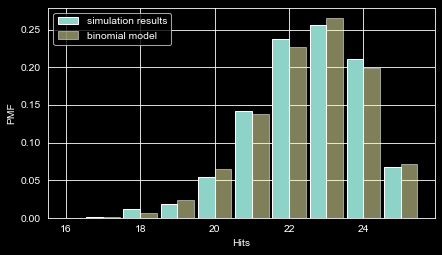

In [10]:
from thinkstats import two_bar_plots

two_bar_plots(pmf_sim, pmf_binom)
decorate(xlabel="Hits", ylabel="PMF")

In [11]:
import os
import pandas as pd

filename = "Shooting_at_the_2020_Summer_Olympics_Mens_skeet"

os.chdir('../data')
tables = pd.read_html(filename)
os.chdir('../my-work')

table = tables[6]
table.head()

,Rank,Athlete,Country,1,2,3,4,5,Total[3],Shoot-off,Notes
0,1,Éric Delaunay,France,25,25,25,24,25,124,+6,"Q, OR"
1,2,Tammaro Cassandro,Italy,24,25,25,25,25,124,+5,"Q, OR"
2,3,Eetu Kallioinen,Finland,25,25,24,25,24,123,NaN,Q
3,4,Vincent Hancock,United States,25,25,25,25,22,122,+8,Q
4,5,Abdullah Al-Rashidi,Kuwait,25,25,24,25,23,122,+7,Q


In [12]:
columns = ["1", "2", "3", "4", "5"]
results = table[columns].values.flatten()

In [13]:
total_shots = 25 * len(results)
total_hits = results.sum()
n, total_shots, total_hits

(25, 3750, np.int64(3575))

In [14]:
p = total_hits / total_shots
p

np.float64(0.9533333333333334)

In [15]:
ps = binomial_pmf(ks, n, p)
pmf_binom = Pmf(ps, ks, name="binomial model")

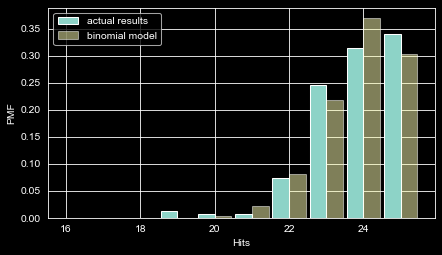

In [16]:
pmf_results = Pmf.from_seq(results, name="actual results")

two_bar_plots(pmf_results, pmf_binom)
decorate(xlabel="Hits", ylabel="PMF")

## 5.2. The Poisson Distribution

https://youtu.be/cPOChr_kuQs?si=8MDoWmtkubYaJx_J

In [17]:
n = 3600
m = 6
p = m / 3600
p

0.0016666666666666668

In [18]:
def simulate_goals(n, p):
    return flip(n, p).sum()

In [19]:
goals = [simulate_goals(n, p) for i in range(1001)]
np.mean(goals)

np.float64(6.021978021978022)

In [20]:
goals = [simulate_goals(n, p) for i in range(1001)]
np.mean(goals)

np.float64(5.92007992007992)

In [21]:
from scipy.special import factorial


def poisson_pmf(k, lam):
    """Compute the Poisson PMF.

    k (int or array-like): The number of occurrences
    lam (float): The rate parameter (λ) of the Poisson distribution

    returns: float or ndarray
    """
    return (lam**k) * np.exp(-lam) / factorial(k)

In [22]:
lam = 6
ks = np.arange(20)
ps = poisson_pmf(ks, lam)
pmf_poisson = Pmf(ps, ks, name="Poisson model")

In [23]:
pmf_poisson.normalize()
pmf_poisson.mean()

np.float64(5.999925498375129)

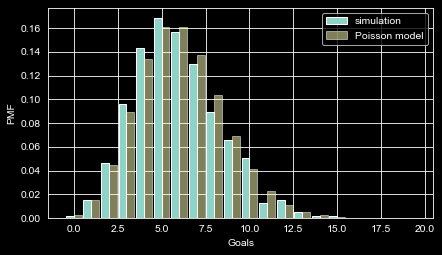

In [24]:
pmf_sim = Pmf.from_seq(goals, name="simulation")

two_bar_plots(pmf_sim, pmf_poisson)
decorate(xlabel="Goals", ylabel="PMF")

## 5.3. The Exponential Distribution

In [25]:
n = 3600
m = 6
p = m / 3600
p

0.0016666666666666668

In [26]:
def simulate_first_goal(n, p):
    return flip(n, p).argmax()

In [27]:
np.random.seed(3)

In [28]:
first_goal_times = [simulate_first_goal(n, p) for i in range(1001)]
mean = np.mean(first_goal_times)
mean

np.float64(597.7902097902098)

When n is large and p is small, we can show mathematically that the expected time until the first goal follows an exponential distribution.

In [29]:
def exponential_cdf(x, lam):
    """Compute the exponential CDF.

    x: float or sequence of floats
    lam: rate parameter

    returns: float or NumPy array of cumulative probability
    """
    return 1 - np.exp(-lam * x)

The value of lam, is the average number of events per unit of time – in this example it is goals per second. We can use the mean of the simulated results to compute lam.

In [30]:
lam = 1 / mean
lam

np.float64(0.0016728276636563566)

 The NumPy function linspace creates an array of equally-spaced values; in this example, it computes 201 values from 0 to 3600, including both.

In [31]:
from empiricaldist import Cdf

ts = np.linspace(0, 3600, 201)
ps = exponential_cdf(ts, lam)
cdf_expo = Cdf(ps, ts, name="exponential model")

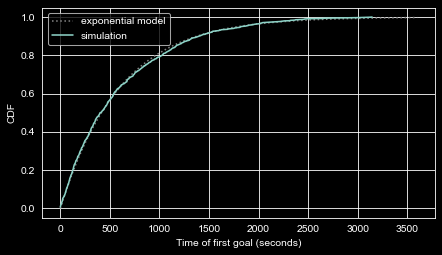

In [32]:
cdf_sim = Cdf.from_seq(first_goal_times, name="simulation")

cdf_expo.plot(ls=":", color="gray")
cdf_sim.plot()

decorate(xlabel="Time of first goal (seconds)", ylabel="CDF")

In [33]:
os.chdir('../data')
filename = "nhl_2023_2024.hdf"

with pd.HDFStore(filename, "r") as store:
    keys = store.keys()

In [34]:
firsts = []

for key in keys:
    times = pd.read_hdf(filename, key=key)
    if len(times) > 0:
        firsts.append(times[0])
    else:
        firsts.append(np.nan)

os.chdir('../my-work')


In [35]:
lam = 1 / np.nanmean(firsts)
lam

np.float64(0.0015121567467720825)

In [36]:
ps = exponential_cdf(ts, lam)
cdf_expo = Cdf(ps, ts, name="exponential model")

In [37]:
cdf_firsts = Cdf.from_seq(firsts, name="data", dropna=False)
cdf_firsts.tail()

,probs
3286.0,0.996951
3581.0,0.997713
NaN,1.000000


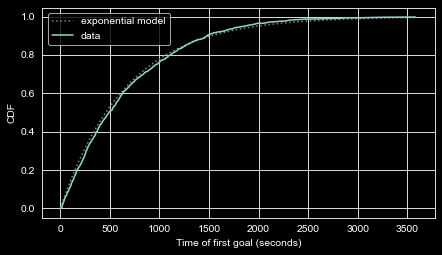

In [38]:
cdf_expo.plot(ls=":", color="gray")
cdf_firsts.plot()

decorate(xlabel="Time of first goal (seconds)", ylabel="CDF")

The underlying assumption of these models – the Poisson model of goals and the exponential model of times – is that a goal is equally likely during any second of a game. If you ask a hockey fan whether that’s true, they would say no, and they would be right – the real world violates assumptions like these in many ways.

## 5.4. The Normal Distribution

https://www.youtube.com/watch?v=rzFX5NWojp0

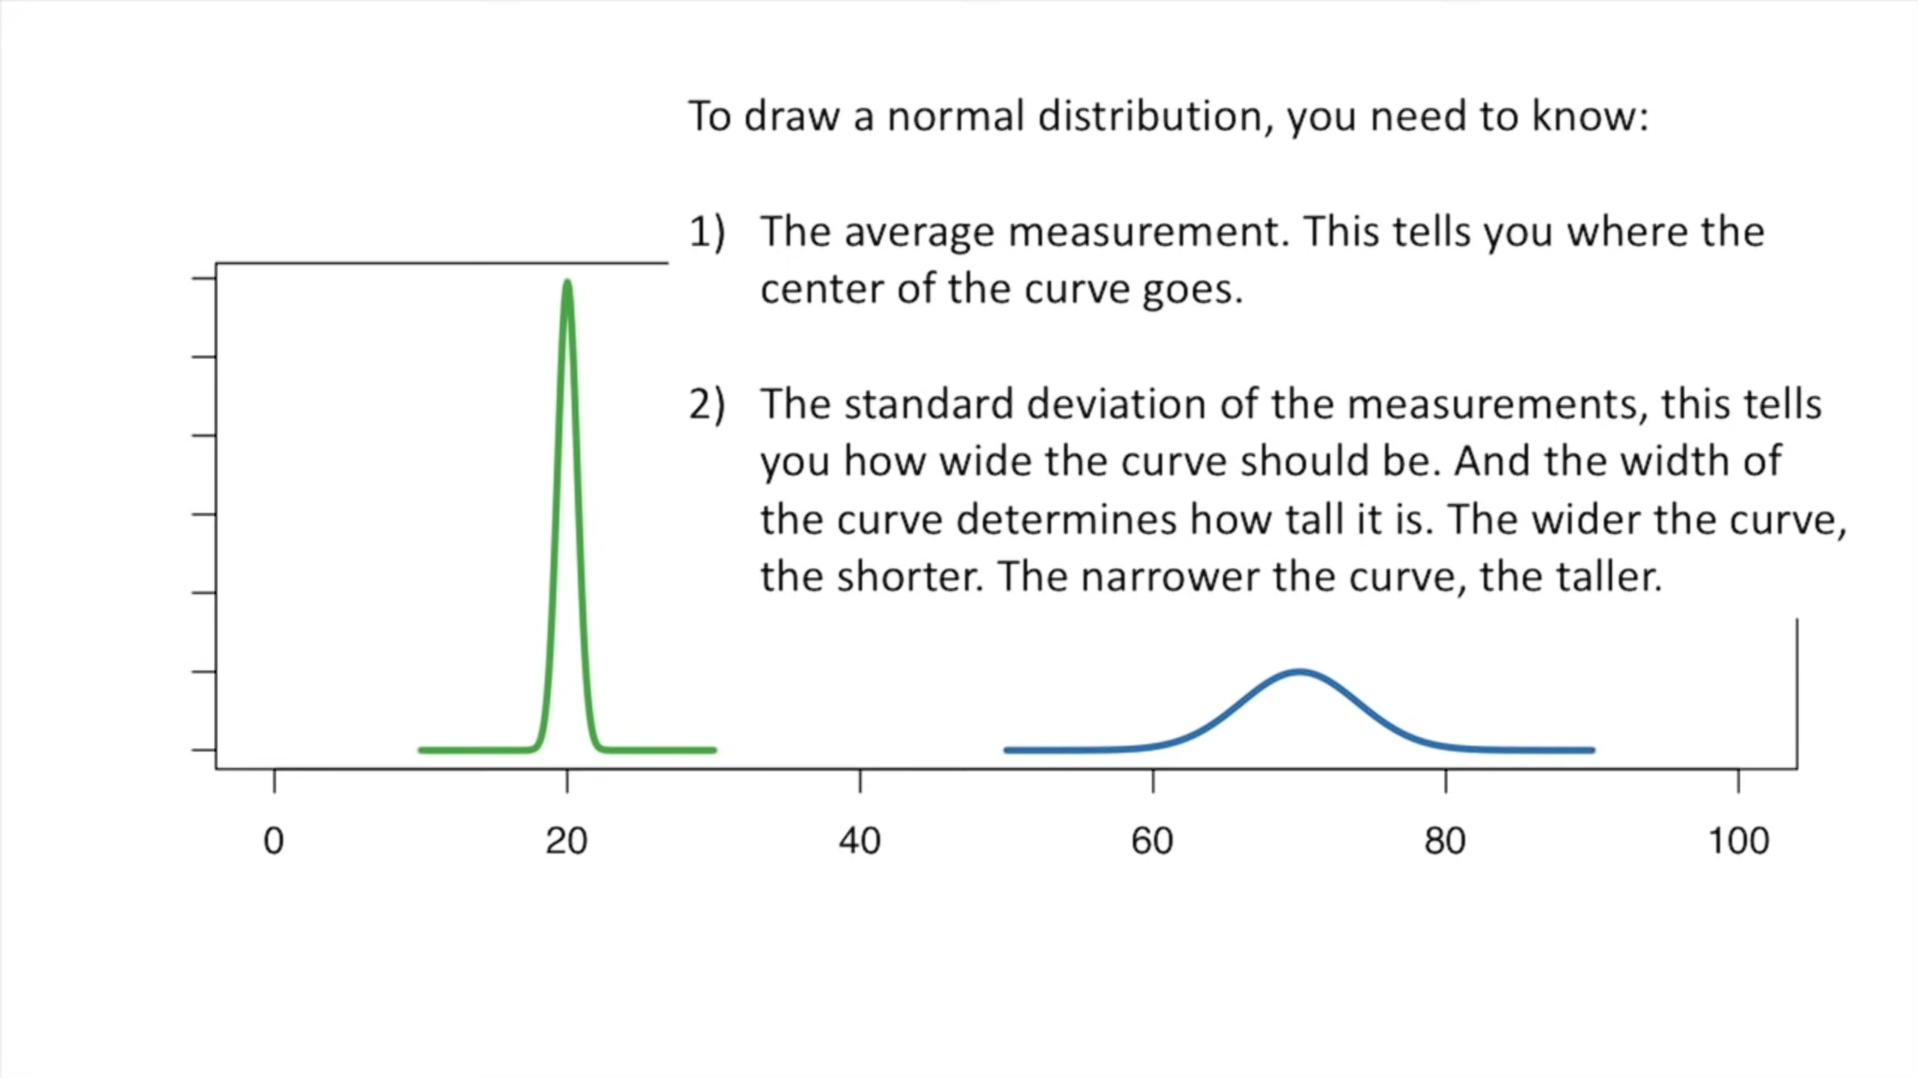

Suppose that each day, a pumpkin gains 1 pound if the weather is bad, 2 pounds if the weather is fair, and 3 pounds if the weather is good. And suppose the weather each day is bad, fair, or good with the same probability.

We can use the following function to simulate this model for n days and return the total of the weight gains.

In [39]:
def simulate_growth(n):
    choices = [1, 2, 3]
    gains = np.random.choice(choices, n)
    return gains.sum()

In [40]:
sim_weights = [simulate_growth(100) for i in range(1001)]
m, s = np.mean(sim_weights), np.std(sim_weights)
m, s

(np.float64(199.37062937062936), np.float64(8.388630840376777))

In [41]:
from scipy.stats import norm


def make_normal_model(data):
    m, s = np.mean(data), np.std(data)
    low, high = m - 4 * s, m + 4 * s
    qs = np.linspace(low, high, 201)
    ps = norm.cdf(qs, m, s)
    return Cdf(ps, qs, name="normal model")

In [42]:
cdf_model = make_normal_model(sim_weights)

In [43]:
cdf_sim_weights = Cdf.from_seq(sim_weights, name="simulation")

In [44]:
cdf_sim_weights = Cdf.from_seq(sim_weights, name="simulation")

In [45]:
def two_cdf_plots(cdf_model, cdf_data, xlabel="", **options):
    cdf_model.plot(ls=":", color="gray")
    cdf_data.plot(**options)
    decorate(xlabel=xlabel, ylabel="CDF")

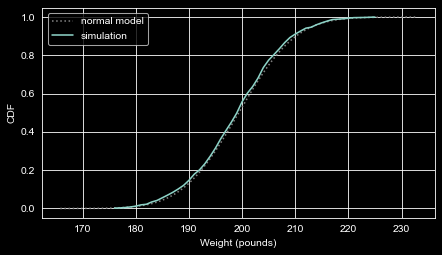

In [46]:
two_cdf_plots(cdf_model, cdf_sim_weights, xlabel="Weight (pounds)")

In [50]:
try:
    import statadict
except ImportError:
    %pip install statadict

In [51]:
import nsfg

os.chdir('../data')
preg = nsfg.read_fem_preg()
os.chdir('../my-work')

birth_weights = preg["totalwgt_lb"].dropna()

C:\Users\xannx\PycharmProjects\ThinkStats\my-work\../nb\nsfg.py:220: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["totalwgt_lb"] = df.birthwgt_lb + df.birthwgt_oz / 16.0


In [52]:
m, s = np.mean(birth_weights), np.std(birth_weights)
m, s

(np.float64(7.265628457623368), np.float64(1.40821553384062))

To reduce the effect of the outliers on the estimated mean and standard deviation, we’ll use the SciPy function trimboth to remove the highest and lowest values.

In [53]:
from scipy.stats import trimboth

trimmed = trimboth(birth_weights, 0.01)
m, s = np.mean(trimmed), np.std(trimmed)
m, s

(np.float64(7.280883100022579), np.float64(1.2430657948614345))

In [54]:
cdf_model = make_normal_model(trimmed)

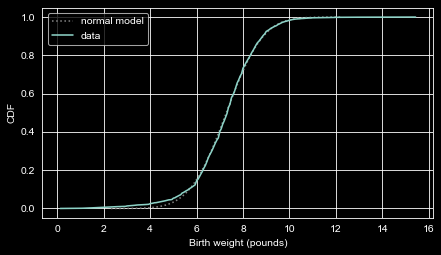

In [55]:
cdf_birth_weight = Cdf.from_seq(birth_weights, name='data')

two_cdf_plots(cdf_model, cdf_birth_weight, xlabel="Birth weight (pounds)")

## 5.5. The Lognormal Distribution

In [56]:
def simulate_proportionate_growth(n):
    choices = [1.03, 1.05, 1.07]
    gains = np.random.choice(choices, n)
    return gains.prod()

In [57]:
sim_weights = [simulate_proportionate_growth(100) for i in range(1001)]
np.mean(sim_weights), np.std(sim_weights)

(np.float64(130.80183363824722), np.float64(20.956047434921466))

In [58]:
log_sim_weights = np.log10(sim_weights)
m, s = np.mean(log_sim_weights), np.std(log_sim_weights)
m, s

(np.float64(2.1111299372609933), np.float64(0.06898607064749827))

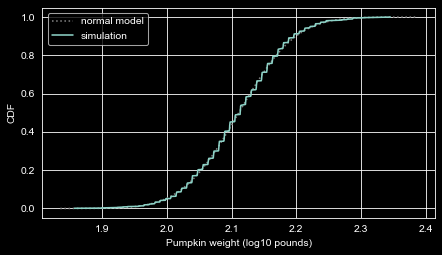

In [59]:
cdf_model = make_normal_model(log_sim_weights)
cdf_log_sim_weights = Cdf.from_seq(log_sim_weights, name="simulation")

two_cdf_plots(
    cdf_model, cdf_log_sim_weights, xlabel="Pumpkin weight (log10 pounds)"
)

If people are like pumpkins, where the change in weight from year to year is proportionate to their current weight, we might expect the distribution of adult weights to follow a lognormal distribution. Let’s find out.

In [62]:
from thinkstats import read_brfss

os.chdir('../data')
brfss = read_brfss()
os.chdir('../my-work')

In [63]:
adult_weights = brfss["wtkg2"].dropna()
m, s = np.mean(adult_weights), np.std(adult_weights)
m, s

(np.float64(78.99245299685809), np.float64(19.546132387397257))

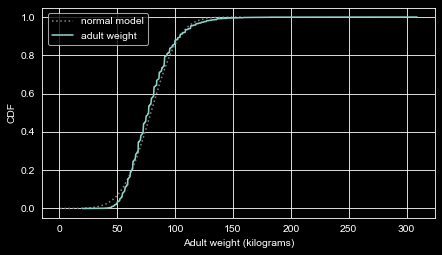

In [64]:
cdf_model = make_normal_model(adult_weights)
cdf_adult_weights = Cdf.from_seq(adult_weights, name="adult weight")

two_cdf_plots(cdf_model, cdf_adult_weights, xlabel="Adult weight (kilograms)")

In [65]:
log_adult_weights = np.log10(adult_weights)
cdf_model = make_normal_model(log_adult_weights)

cdf_log_adult_weights = Cdf.from_seq(log_adult_weights, name="log adult weight")

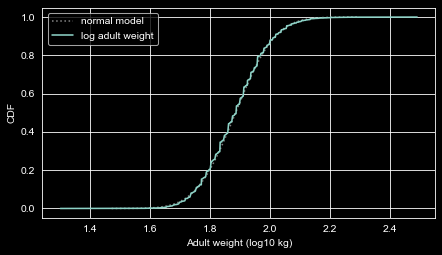

In [66]:
two_cdf_plots(cdf_model, cdf_log_adult_weights, xlabel="Adult weight (log10 kg)")

But it is important to remember that all models are imperfect. Data from the real world never fit a theoretical distribution perfectly. People sometimes talk as if data are generated by models; for example, they might say that the distribution of human heights is normal, or the distribution of income is lognormal. Taken literally, these claims cannot be true – there are always differences between the real world and mathematical models.


## 5.8. Exercises

### 5.8.1. Exercise 5.1

In the NSFG respondent file, the numfmhh column records the “number of family members in” each respondent’s household. We can use read_fem_resp to read the file, and query to select respondents who were 25 or older when they were interviewed.

In [68]:
from nsfg import read_fem_resp

os.chdir('../data')
resp = read_fem_resp()
os.chdir('../my-work')

C:\Users\xannx\PycharmProjects\ThinkStats\my-work\../nb\nsfg.py:191: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  resp["agemarry"] = (resp.cmmarrhx - resp.cmbirth) / 12.0
C:\Users\xannx\PycharmProjects\ThinkStats\my-work\../nb\nsfg.py:192: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  resp["age"] = (resp.cmintvw - resp.cmbirth) / 12.0
C:\Users\xannx\PycharmProjects\ThinkStats\my-work\../nb\nsfg.py:195: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has

In [70]:
older = resp.query("age >= 25")
num_family = older["numfmhh"]

### Compute the Pmf of numfmhh for these older respondents and compare it with a Poisson distribution with the same mean. How well does the Poisson model fit the data?

In [74]:
pmf_family = Pmf.from_seq(num_family.dropna(), name="actual")
pmf_family

,probs
numfmhh,
0,0.118334
1,0.229272
2,0.239587
3,0.231608
4,0.120475
5,0.039510
6,0.013429
7,0.007785


In [75]:
lam = pmf_family.mean()
lam

np.float64(2.2177890229661346)

In [76]:
ks = np.arange(0, num_family.max() + 1)
ps = poisson_pmf(ks, lam)
pmf_poisson = Pmf(ps, ks, name="Poisson model")
pmf_poisson.normalize()

np.float64(0.9979229774988587)

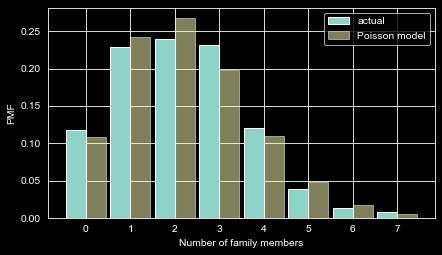

In [77]:
two_bar_plots(pmf_family, pmf_poisson)
decorate(xlabel="Number of family members", ylabel="PMF")